# Claude Opus Thinking Effort Analysis

This notebook runs the thinking effort experiment multiple times at each effort level and analyzes the pass@k results.

In [1]:
import subprocess
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

In [2]:
# Number of trials per effort level
N_TRIALS = 20

# Effort levels to test
EFFORT_LEVELS = ['low', 'medium', 'high']

# Results file
RESULTS_FILE = Path('thinking_effort_results.json')

## Run Experiments

Run the thinking effort script 20 times at each effort level. This will take some time as it makes API calls to Claude Opus.

In [ ]:
# Clear previous results file (optional - comment out to append to existing results)
overwrite = False

if overwrite:
    if RESULTS_FILE.exists():
        RESULTS_FILE.unlink()
        print(f"Cleared previous results from {RESULTS_FILE}")
    

Cleared previous results from thinking_effort_results.json


In [4]:
# Run experiments
print(f"Running {N_TRIALS} trials for each effort level...\n")

for effort in EFFORT_LEVELS:
    print(f"\n{'='*60}")
    print(f"Running {N_TRIALS} trials with effort level: {effort.upper()}")
    print(f"{'='*60}\n")
    
    for trial in tqdm(range(N_TRIALS), desc=f"{effort} trials"):
        try:
            # Run the thinking effort script
            result = subprocess.run(
                ['python', 'thinking_effort.py', effort],
                capture_output=True,
                text=True,
                timeout=300  # 5 minute timeout per trial
            )
            
            if result.returncode != 0:
                print(f"\nWarning: Trial {trial+1} failed with return code {result.returncode}")
                
        except subprocess.TimeoutExpired:
            print(f"\nWarning: Trial {trial+1} timed out")
        except Exception as e:
            print(f"\nError in trial {trial+1}: {e}")

print(f"\n\n{'='*60}")
print("All trials complete!")
print(f"{'='*60}")

Running 20 trials for each effort level...


Running 20 trials with effort level: LOW



low trials: 100%|██████████| 20/20 [01:51<00:00,  5.57s/it]



Running 20 trials with effort level: MEDIUM



medium trials: 100%|██████████| 20/20 [02:37<00:00,  7.89s/it]



Running 20 trials with effort level: HIGH



high trials: 100%|██████████| 20/20 [04:58<00:00, 14.92s/it]



All trials complete!


## Load and Analyze Results

In [5]:
# Load results
with open(RESULTS_FILE, 'r') as f:
    results = json.load(f)

df = pd.DataFrame(results)
print(f"Loaded {len(df)} results\n")

# Show summary statistics
print("Results by effort level:")
print(df.groupby('effort_level')['tests_passed'].agg(['count', 'sum', 'mean']))
print()

df.head()

Loaded 60 results

Results by effort level:
              count  sum  mean
effort_level                  
high             20   20   1.0
low              20    0   0.0
medium           20    0   0.0



,timestamp,effort_level,tests_passed,thinking_length,response_length,extracted_code_length,response_time_seconds,usage
0,2026-02-15T12:11:37.880483,low,False,0,537,725,3.464366,"{'input_tokens': 760, 'output_tokens': 157}"
1,2026-02-15T12:11:43.131557,low,False,0,537,725,3.550332,"{'input_tokens': 760, 'output_tokens': 157}"
2,2026-02-15T12:11:48.226215,low,False,0,537,725,3.388626,"{'input_tokens': 760, 'output_tokens': 157}"
3,2026-02-15T12:11:53.499079,low,False,0,537,725,3.559658,"{'input_tokens': 760, 'output_tokens': 157}"
4,2026-02-15T12:11:58.857982,low,False,0,537,725,3.672234,"{'input_tokens': 760, 'output_tokens': 157}"


## Calculate Pass@k Metrics

Pass@k measures the probability that at least one of k attempts succeeds. This is a common metric for evaluating code generation models.

In [6]:
def calculate_pass_at_k(n, c, k):
    """
    Calculate pass@k metric.
    
    Args:
        n: total number of samples
        c: number of correct samples
        k: k in pass@k
    
    Returns:
        Probability that at least one of k samples is correct
    """
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))


# Calculate pass@k for different k values
k_values = [1, 5, 10, 20]
pass_at_k_results = []

for effort in EFFORT_LEVELS:
    effort_df = df[df['effort_level'] == effort]
    n_total = len(effort_df)
    n_correct = effort_df['tests_passed'].sum()
    
    for k in k_values:
        if k <= n_total:
            pass_k = calculate_pass_at_k(n_total, n_correct, k)
            pass_at_k_results.append({
                'effort_level': effort,
                'k': k,
                'pass@k': pass_k,
                'n_trials': n_total,
                'n_passed': n_correct
            })

pass_k_df = pd.DataFrame(pass_at_k_results)
print("Pass@k results:\n")
print(pass_k_df.pivot(index='effort_level', columns='k', values='pass@k').round(3))

Pass@k results:

k              1    5    10   20
effort_level                    
high          1.0  1.0  1.0  1.0
low           0.0  0.0  0.0  0.0
medium        0.0  0.0  0.0  0.0


In [7]:
asdfds

NameError: name 'asdfds' is not defined

## Visualize Results

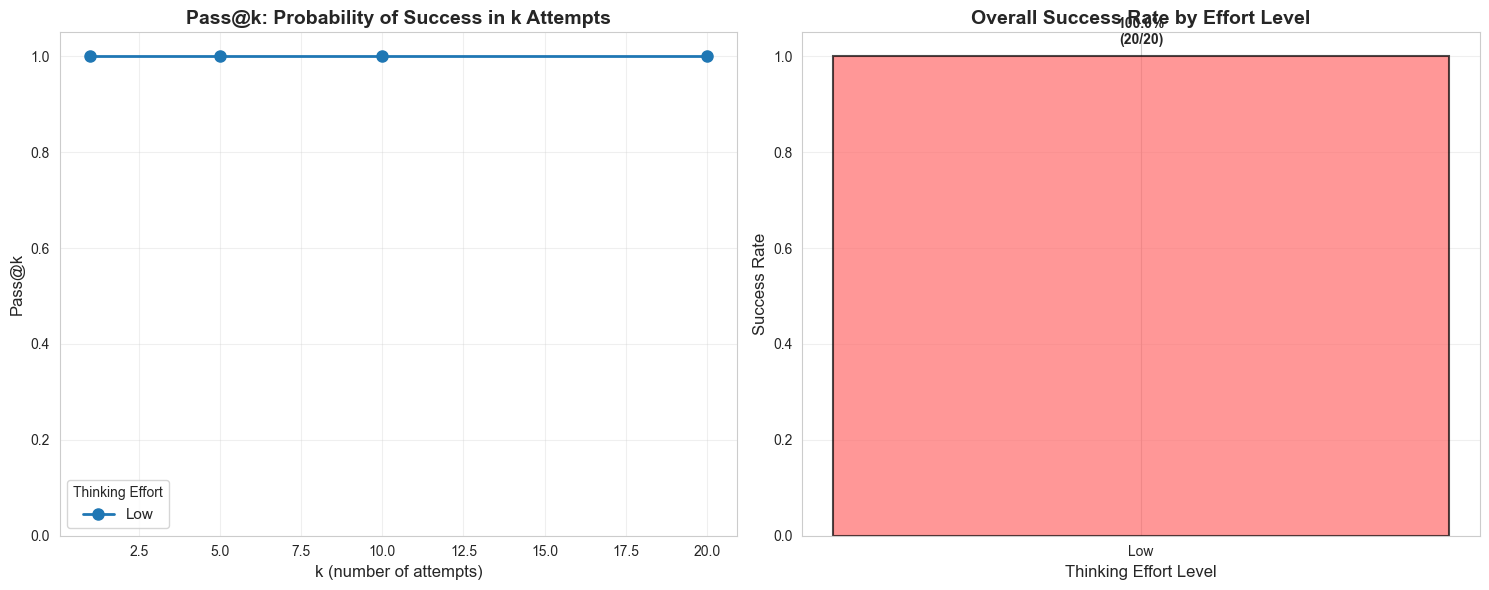


Plot saved as 'thinking_effort_analysis.png'


In [ ]:
# Plot pass@k curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Pass@k curves
for effort in EFFORT_LEVELS:
    effort_data = pass_k_df[pass_k_df['effort_level'] == effort]
    ax1.plot(effort_data['k'], effort_data['pass@k'], marker='o', 
             linewidth=2, markersize=8, label=effort.capitalize())

ax1.set_xlabel('k (number of attempts)', fontsize=12)
ax1.set_ylabel('Pass@k', fontsize=12)
ax1.set_title('Pass@k: Probability of Success in k Attempts', fontsize=14, fontweight='bold')
ax1.legend(title='Thinking Effort', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Success rate (pass@1)
success_rates = df.groupby('effort_level')['tests_passed'].mean()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax2.bar(range(len(EFFORT_LEVELS)), 
               [success_rates[e] for e in EFFORT_LEVELS],
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Thinking Effort Level', fontsize=12)
ax2.set_ylabel('Success Rate', fontsize=12)
ax2.set_title('Overall Success Rate by Effort Level', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(EFFORT_LEVELS)))
ax2.set_xticklabels([e.capitalize() for e in EFFORT_LEVELS])
ax2.set_ylim([0, 1.05])
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, effort) in enumerate(zip(bars, EFFORT_LEVELS)):
    height = bar.get_height()
    n_passed = df[df['effort_level'] == effort]['tests_passed'].sum()
    n_total = len(df[df['effort_level'] == effort])
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.1%}\n({n_passed}/{n_total})',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('thinking_effort_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'thinking_effort_analysis.png'")

## Token Usage Analysis

In [9]:
# Extract token usage
df['input_tokens'] = df['usage'].apply(lambda x: x['input_tokens'])
df['output_tokens'] = df['usage'].apply(lambda x: x['output_tokens'])
df['total_tokens'] = df['input_tokens'] + df['output_tokens']

# Token usage by effort level
token_stats = df.groupby('effort_level')[['input_tokens', 'output_tokens', 'total_tokens']].agg(['mean', 'std'])
print("\nToken usage statistics by effort level:")
print(token_stats.round(0))


Token usage statistics by effort level:
             input_tokens      output_tokens       total_tokens      
                     mean  std          mean   std         mean   std
effort_level                                                         
high                760.0  0.0         928.0  33.0       1688.0  33.0
low                 760.0  0.0         157.0   0.0        917.0   0.0
medium              760.0  0.0         320.0  43.0       1080.0  43.0


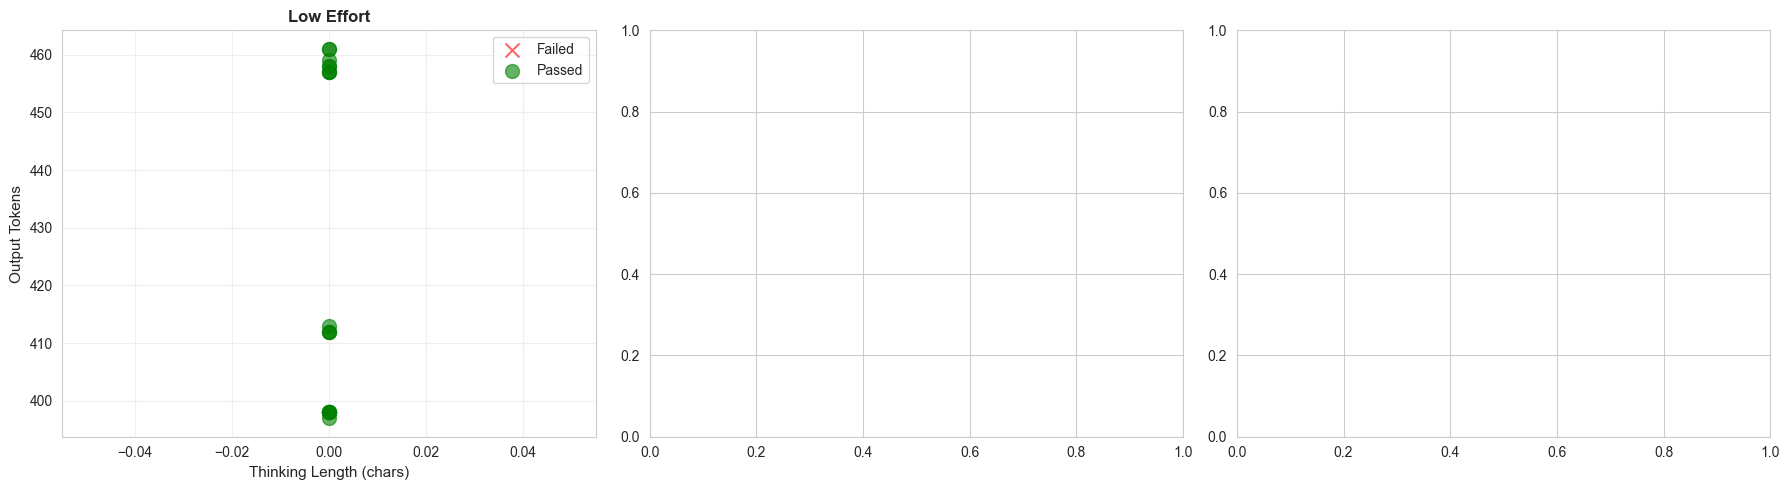


Plot saved as 'thinking_effort_tokens.png'


In [ ]:
# Plot token usage vs success
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, effort in enumerate(EFFORT_LEVELS):
    effort_df = df[df['effort_level'] == effort]
    
    passed = effort_df[effort_df['tests_passed'] == True]
    failed = effort_df[effort_df['tests_passed'] == False]
    
    axes[idx].scatter(failed['thinking_length'], failed['output_tokens'], 
                     color='red', alpha=0.6, s=100, label='Failed', marker='x')
    axes[idx].scatter(passed['thinking_length'], passed['output_tokens'], 
                     color='green', alpha=0.6, s=100, label='Passed', marker='o')
    
    axes[idx].set_xlabel('Thinking Length (chars)', fontsize=11)
    axes[idx].set_ylabel('Output Tokens', fontsize=11)
    axes[idx].set_title(f'{effort.capitalize()} Effort', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('thinking_effort_tokens.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'thinking_effort_tokens.png'")

## Response Time Analysis


Response time statistics by effort level (seconds):
               mean   std    min    max
effort_level                           
high          13.04  0.73  11.90  14.97
low            3.85  1.24   2.99   8.99
medium         6.15  0.41   5.42   6.79


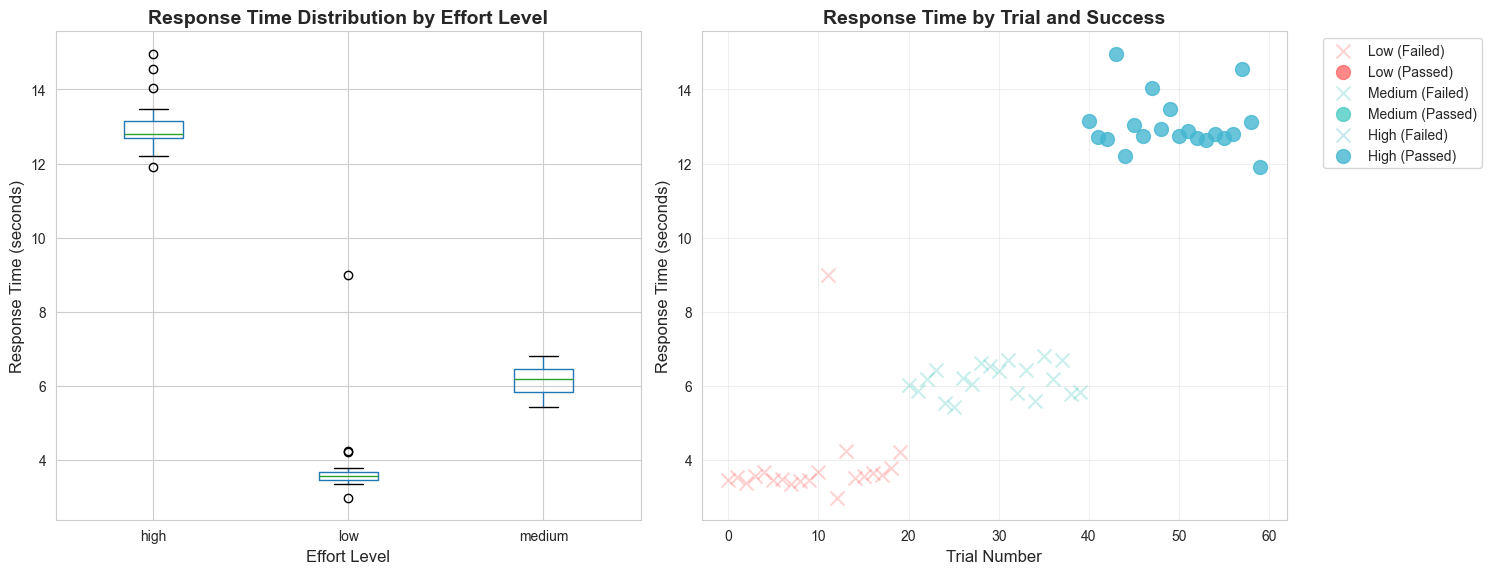


Plot saved as 'thinking_effort_response_time.png'


In [8]:
# Response time statistics by effort level
response_time_stats = df.groupby('effort_level')['response_time_seconds'].agg(['mean', 'std', 'min', 'max'])
print("\nResponse time statistics by effort level (seconds):")
print(response_time_stats.round(2))

# Plot response time distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
df.boxplot(column='response_time_seconds', by='effort_level', ax=ax1)
ax1.set_xlabel('Effort Level', fontsize=12)
ax1.set_ylabel('Response Time (seconds)', fontsize=12)
ax1.set_title('Response Time Distribution by Effort Level', fontsize=14, fontweight='bold')
ax1.get_figure().suptitle('')  # Remove default title

# Response time vs success
for effort, color in zip(EFFORT_LEVELS, ['#FF6B6B', '#4ECDC4', '#45B7D1']):
    effort_df = df[df['effort_level'] == effort]
    passed = effort_df[effort_df['tests_passed'] == True]
    failed = effort_df[effort_df['tests_passed'] == False]
    
    ax2.scatter(failed.index, failed['response_time_seconds'], 
               color=color, alpha=0.3, s=100, marker='x', label=f'{effort.capitalize()} (Failed)')
    ax2.scatter(passed.index, passed['response_time_seconds'], 
               color=color, alpha=0.8, s=100, marker='o', label=f'{effort.capitalize()} (Passed)')

ax2.set_xlabel('Trial Number', fontsize=12)
ax2.set_ylabel('Response Time (seconds)', fontsize=12)
ax2.set_title('Response Time by Trial and Success', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('thinking_effort_response_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'thinking_effort_response_time.png'")

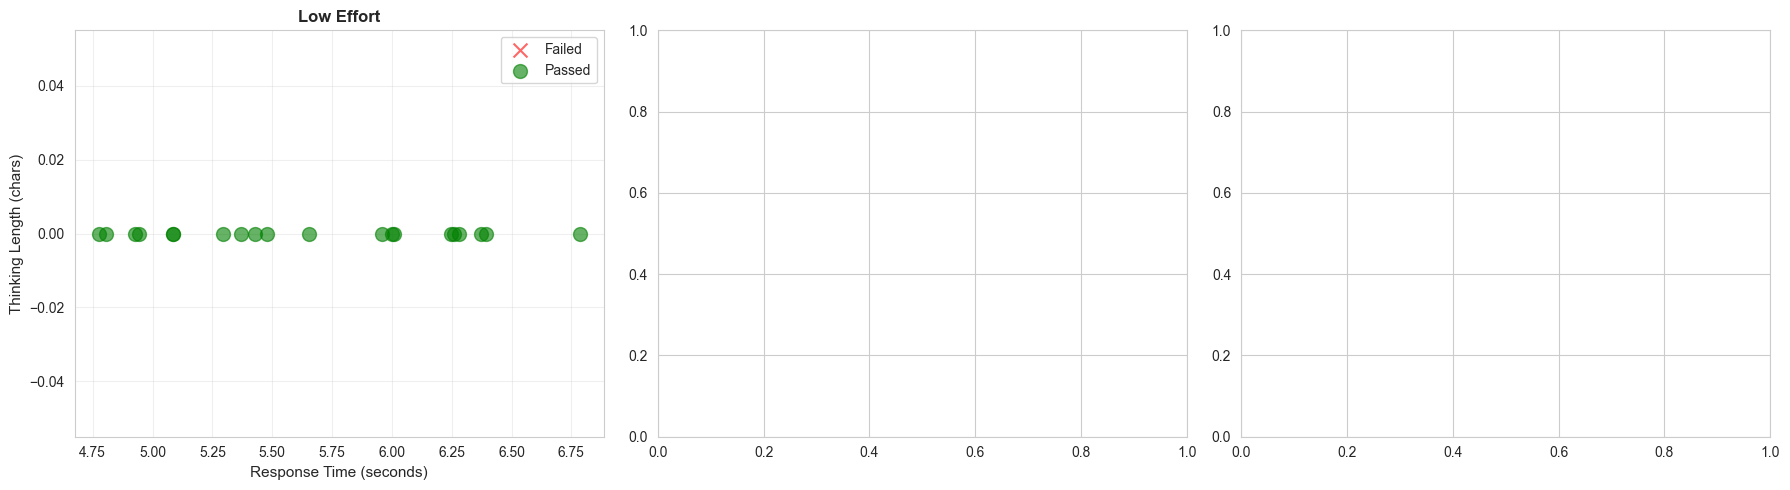


Plot saved as 'thinking_effort_time_vs_thinking.png'


Correlations for successful attempts:

Low:
                       response_time_seconds  thinking_length  output_tokens
response_time_seconds                  1.000              NaN          0.905
thinking_length                          NaN              NaN            NaN
output_tokens                          0.905              NaN          1.000


In [ ]:
# Correlation between response time, thinking, and success
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, effort in enumerate(EFFORT_LEVELS):
    effort_df = df[df['effort_level'] == effort]
    
    passed = effort_df[effort_df['tests_passed'] == True]
    failed = effort_df[effort_df['tests_passed'] == False]
    
    axes[idx].scatter(failed['response_time_seconds'], failed['thinking_length'], 
                     color='red', alpha=0.6, s=100, label='Failed', marker='x')
    axes[idx].scatter(passed['response_time_seconds'], passed['thinking_length'], 
                     color='green', alpha=0.6, s=100, label='Passed', marker='o')
    
    axes[idx].set_xlabel('Response Time (seconds)', fontsize=11)
    axes[idx].set_ylabel('Thinking Length (chars)', fontsize=11)
    axes[idx].set_title(f'{effort.capitalize()} Effort', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('thinking_effort_time_vs_thinking.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'thinking_effort_time_vs_thinking.png'")

# Calculate correlation for successful attempts
print("\n\nCorrelations for successful attempts:")
for effort in EFFORT_LEVELS:
    effort_passed = df[(df['effort_level'] == effort) & (df['tests_passed'] == True)]
    if len(effort_passed) > 1:
        corr = effort_passed[['response_time_seconds', 'thinking_length', 'output_tokens']].corr()
        print(f"\n{effort.capitalize()}:")
        print(corr.round(3))

## Summary Statistics

In [ ]:
# Create summary table
summary = []
for effort in EFFORT_LEVELS:
    effort_df = df[df['effort_level'] == effort]
    summary.append({
        'Effort Level': effort.capitalize(),
        'N Trials': len(effort_df),
        'N Passed': effort_df['tests_passed'].sum(),
        'Success Rate': f"{effort_df['tests_passed'].mean():.1%}",
        'Avg Response Time (s)': f"{effort_df['response_time_seconds'].mean():.1f}",
        'Avg Thinking Tokens': f"{effort_df['thinking_length'].mean():.0f}",
        'Avg Output Tokens': f"{effort_df['output_tokens'].mean():.0f}",
        'Avg Total Tokens': f"{effort_df['total_tokens'].mean():.0f}",
    })

summary_df = pd.DataFrame(summary)
print("\nSummary Statistics:")
print(summary_df.to_string(index=False))


Summary Statistics:
Effort Level  N Trials  N Passed Success Rate Avg Response Time (s) Avg Thinking Tokens Avg Output Tokens Avg Total Tokens
         Low        20        20       100.0%                   5.7                   0               425             1112


## Export Results

In [ ]:
# Save processed results
df.to_csv('thinking_effort_analysis.csv', index=False)
pass_k_df.to_csv('thinking_effort_pass_at_k.csv', index=False)

print("Results exported to:")
print("  - thinking_effort_analysis.csv")
print("  - thinking_effort_pass_at_k.csv")

Results exported to:
  - thinking_effort_analysis.csv
  - thinking_effort_pass_at_k.csv
